# Active Experimental Design under Noise and Budget Constraints

In many experiments we aim to discover how a property depends on composition or processing conditions. This is often a case for characterization by XRD, SPM, Raman etc. of spread combinatorial libraries, where a continuous range of compositions is explored on a single substrate.

A mainstream approach for automating such experiments is Bayesian optimization (BO), where a surrogate model (e.g. Gaussian process) is used to predict the property and guide the selection of the next measurement in an active, closed-loop manner.

However, classical BO typically assumes idealized conditions and does not explicitly account for key experimental constraints, such as:

- measurement noise that depends on acquisition time,
- limited experimental budget,
- and cost of moving between measurement locations.

In this challenge, the goal is to design a strategy that, using a surrogate model, decides:

- **where to measure**,
- **in what order**,
- and **for how long**,

in order to efficiently explore and recover the underlying functional dependence under these realistic conditions.

###gif_Classical BO with GP surrogate model



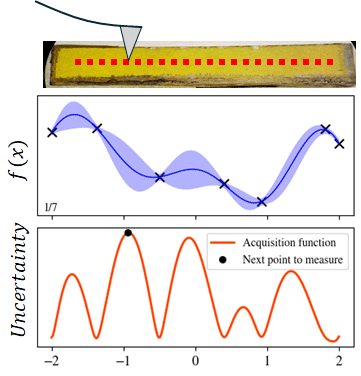

## Functions

In [2]:
# !pip install gpytorch

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

In [21]:
#@title target function

# F1 — Smooth unimodal
def unimodal(x):
    x = np.asarray(x)
    res = 0.15 * (x + 2)**2 + 0.03 * (x - 1)**4
    return res
    # return res/res.max()


# F2 — Double-well
def double_well(x):
    x = np.asarray(x)
    res = 0.08 * (x**2 - 4)**2 + 0.15 * x

    return res
    # return res/res.max()


# F3 — Multimodal (Rastrigin-like, 1D)
def multimodal(x):
    x = np.asarray(x)
    res = 10 + x**2 - 7 * np.cos(2 * np.pi * x) + 9 * np.sin(1.4 * np.pi * x)
    # return res/res.max()
    return res



# F4 — Broad + narrow minima
def broad_narrow(x):
    x = np.asarray(x)

    res = (
        1
        - 1.0 * np.exp(-((x + 1.5)**2) / (2 * 0.9**2))
        - 1.6 * np.exp(-((x - 1.0)**2) / (2 * 0.18**2))
    )
    # return res/res.max()
    return res



In [22]:
#@title simple noise models

def noise_constant(x = None, t = None, sigma0=0.1):
    t = np.asarray(t)
    return sigma0 * np.ones_like(t, dtype=float)

def noise_decay_floor(x = None, t = None, sigma_min=0.05, A=0.18, tau=1.0):
    t = np.asarray(t)
    return sigma_min + A * np.exp(-t / tau)

In [23]:
#@title heteroskedastic_noise_model

def make_heteroskedastic_noise_model(f, xlim, n_grid=200, smooth_window=3):
    """
    Build heteroskedastic noise model on a fixed domain.

    Parameters
    ----------
    f : callable
        Ground truth function
    xlim : tuple (xmin, xmax)
        Domain of interest
    """

    xmin, xmax = xlim
    x_grid = np.linspace(xmin, xmax, n_grid)
    y_grid = f(x_grid)

    # gradient
    grad = np.abs(np.gradient(y_grid, x_grid, edge_order=2))

    # smoothing
    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        half = smooth_window // 2
        grad_s = np.pad(grad, pad_width=half, mode="reflect")
        grad = np.convolve(grad_s, kernel, mode="valid")

    # normalization
    scale = np.percentile(grad, 95) + 1e-12
    grad_norm_grid = grad / scale

    def noise_model(x, t, sigma_min=0.05, sigma_max=0.5, tau=1.5):
        x = np.asarray(x, dtype=float)
        t = np.asarray(t, dtype=float)

        g = np.interp(x, x_grid, grad_norm_grid)
        sigma0_x = sigma_min + (sigma_max - sigma_min) * g

        return sigma_min + (sigma0_x - sigma_min) * np.exp(-t / tau)

    return noise_model

In [24]:
#@title measurement simulator

class MeasurementSimulator:
    def __init__(self, ground_truth_model, noise_model, rng=None, **noise_kwargs):
        """
        Parameters
        ----------
        ground_truth_model : callable
            Function f(x)
        noise_model : callable
            Function sigma(x, t, **noise_kwargs)
        rng : None, int, or np.random.Generator
            Random generator or seed
        **noise_kwargs
            Default parameters for noise_model
        """
        self.f = ground_truth_model
        self.noise_model = noise_model
        self.noise_kwargs = noise_kwargs

        if rng is None:
            self.rng = np.random.default_rng()
        elif isinstance(rng, (int, np.integer)):
            self.rng = np.random.default_rng(rng)
        else:
            self.rng = rng

    def measure(self, coords, **noise_kwargs):
        """
        coords : array of shape (N, 2)
            Columns are (x, t)

        Returns
        -------
        y_meas : array of shape (N,)
            Noisy measurements
        """
        coords = np.asarray(coords, dtype=float)

        if coords.ndim != 2 or coords.shape[1] != 2:
            raise ValueError("coords must have shape (N, 2)")

        x = coords[:, 0]
        t = coords[:, 1]

        kwargs = {**self.noise_kwargs, **noise_kwargs}
        sigma = np.asarray(self.noise_model(x, t, **kwargs), dtype=float)
        noise = self.rng.normal(0.0, sigma, size=len(x))

        return self.f(x) + noise

    __call__ = measure

In [25]:
#@title gp functions

import torch
import gpytorch


def gp_predict(x_train, y_train, x_test, training_iter=100, lr=0.1):
    """
    Fit GP on (x_train, y_train) and predict on x_test.

    Parameters
    ----------
    x_train : array-like (N,)
    y_train : array-like (N,)
    x_test  : array-like (M,)

    Returns
    -------
    mean : (M,)
    std  : (M,)
    """

    # convert to torch
    x_train = torch.as_tensor(x_train, dtype=torch.float32)
    y_train = torch.as_tensor(y_train, dtype=torch.float32)
    x_test  = torch.as_tensor(x_test, dtype=torch.float32)

    # ensure 2D inputs
    if x_train.ndim == 1:
        x_train = x_train.unsqueeze(-1)
    if x_test.ndim == 1:
        x_test = x_test.unsqueeze(-1)

    # define model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()

    class GPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super().__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.RBFKernel()
            )

        def forward(self, x):
            mean = self.mean_module(x)
            covar = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean, covar)

    model = GPModel(x_train, y_train, likelihood)

    # train
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for _ in range(training_iter):
        optimizer.zero_grad()
        output = model(x_train)
        loss = -mll(output, y_train)
        loss.backward()
        optimizer.step()

    # predict
    model.eval()
    likelihood.eval()

    with torch.no_grad():
        pred = likelihood(model(x_test))
        mean = pred.mean.cpu().numpy()
        std = pred.stddev.cpu().numpy()

    return mean, std

In [26]:
#@title cost models

def travel_cost(dx, speed=0.5) -> float:
  return abs(dx) / speed


## Introduction

In [27]:
x = np.linspace(-4,4,100) #spatial coordinate (compositional/parameter space)
t = np.linspace(0,10,100) #acquisition time

We suggest selecting one of the following four “ground truth” functions to represent the underlying functionality.

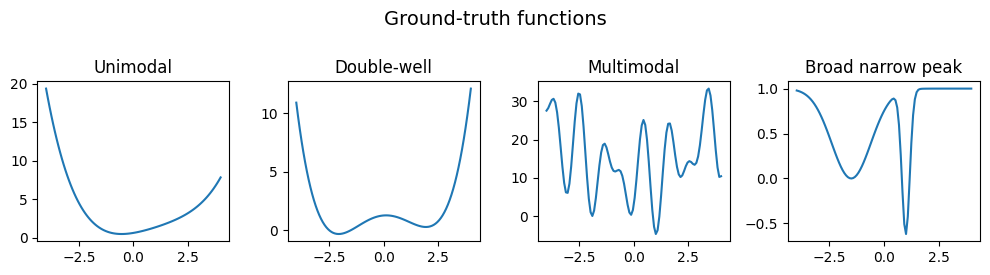

In [28]:
#ground truth functions
fig, ax = plt.subplots(1,4, figsize=(10, 2.7))

ax[0].plot(x, unimodal(x))
ax[1].plot(x, double_well(x))
ax[2].plot(x, multimodal(x))
ax[3].plot(x, broad_narrow(x))

ax[0].set_title('Unimodal')
ax[1].set_title('Double-well')
ax[2].set_title('Multimodal')
ax[3].set_title('Broad narrow peak')

fig.suptitle('Ground-truth functions', y=1, fontsize=14)

plt.tight_layout()

To emulate noisy measurements, we consider two homoscedastic noise models. The first is a **constant noise** model (trivial case), where the measurement precision is independent of acquisition time. The second is a **decaying noise** model, where the noise decreases exponentially with acquisition time and approaches a maximum achievable precision.

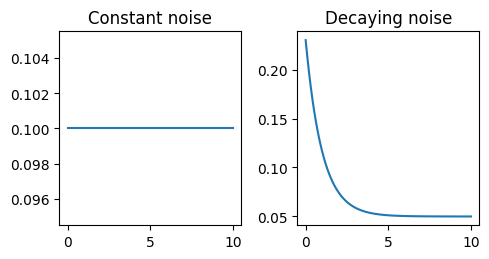

In [29]:
#homoskedastic noise model

fig, ax = plt.subplots(1,2, figsize=(5, 2.7))

ax[0].plot(t, noise_constant(x, t))
ax[0].set_title('Constant noise')
ax[1].plot(t, noise_decay_floor(x, t))
ax[1].set_title('Decaying noise')

plt.tight_layout()

For those seeking more hardcore challenge, we also suggest a **heteroscedastic noise model**, where the measurement noise depends on the location. In our specific case, the noise level is proportional to the local gradient of the underlying function, while still decaying with acquisition time toward a limiting precision.

Text(0.5, 0.98, 'Heteroskedastic noise model')

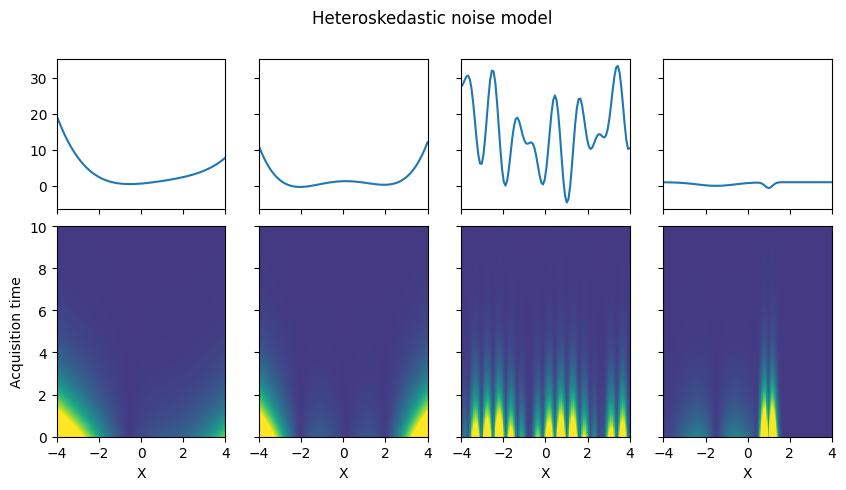

In [30]:
#@title heteroskedastic noise model

funcs = [unimodal, double_well, multimodal, broad_narrow]

fig, ax = plt.subplots(2, 4, figsize=(10, 5),
                       height_ratios=(1,1.5),
                       sharex=True,
                       sharey='row',
                       gridspec_kw={'hspace': 0.05})

for i,ax0_ in enumerate(ax[0]):
  ax0_.plot(x, funcs[i](x))

for i,ax1_ in enumerate(ax[1]):
  noise_model = make_heteroskedastic_noise_model(funcs[i], (-4, 4))
  ax1_.imshow(noise_model(x, t.reshape(-1,1)),
              origin='lower',
              extent=[x.min(), x.max(), t.min(), t.max()],
              vmax=.3, vmin=0)
  ax1_.set_xlabel('X')

ax[1,0].set_ylabel('Acquisition time')

fig.suptitle('Heteroskedastic noise model')


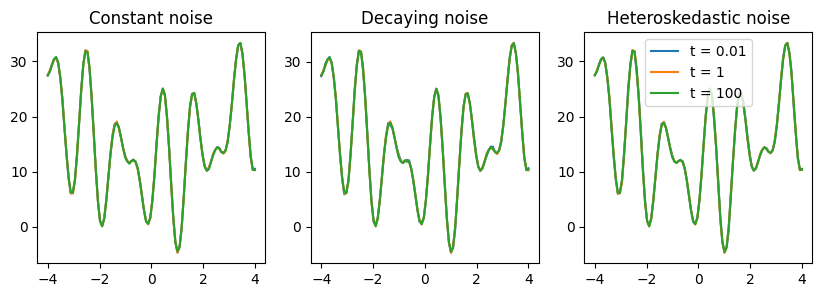

In [31]:
#@title example: grid measurements with different acqusition time

x = np.linspace(-4,4, 100) #x grid

durations = [0.01, 1, 100] #select durations
model = multimodal #select model [unimodal, double_well, multimodal, broad_narrow]

noise_heter_model = make_heteroskedastic_noise_model(model, (-4, 4))

sim_const = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_constant,
    rng=123,
)

sim_decay = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_decay_floor,
    rng=123,
)

sim_heterosk = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_heter_model,
    rng=123,
)

fig, ax = plt.subplots(1, 3, figsize=(10,3))

for d in durations:
  d_ar = np.ones(len(x))*d
  coords = np.vstack([x, d_ar]).T

  ax[0].plot(coords[:,0], sim_const.measure(coords), label = f't = {d}')
  ax[1].plot(coords[:,0], sim_decay.measure(coords), label = f't = {d}')
  ax[2].plot(coords[:,0], sim_heterosk.measure(coords), label = f't = {d}')

ax[0].set_title('Constant noise')
ax[1].set_title('Decaying noise')
ax[2].set_title('Heteroskedastic noise')
ax[2].legend()

In [32]:
#@title example: surrogate modeling

#homoskedatic noise model: [noise_constant, noise_decay_floor]
#ground truth models: [unimodal, double_well, multimodal, broad_narrow]


#If we select the heteroskedastic noise model, we first need to construct it. For the homoskedastic cases, the models are already defined.
noise_heter_model = make_heteroskedastic_noise_model(double_well, xlim=(-4, 4)) #please define the x range

meas_sim = MeasurementSimulator(
    ground_truth_model=double_well,
    noise_model=noise_heter_model,
    rng=123,
)

In [33]:

#define x_grid on the explored interval

x_grid = np.linspace(-4, 4, 500)

# For this example, select 4 random locations in the range (-4, 4)
x = np.random.random(7) * 8 - 4

# Set acquisition time (t = 3) for all locations
t = np.ones(len(x)) * 1

# Form the coordinate array: [[x1, t1], [x2, t2], ...]
coords = np.column_stack([x, t])

#make "measurements"
y = meas_sim.measure(coords)

#surrogate modeling
mean, std = gp_predict(x, y, x_grid, training_iter=100, lr=0.1)

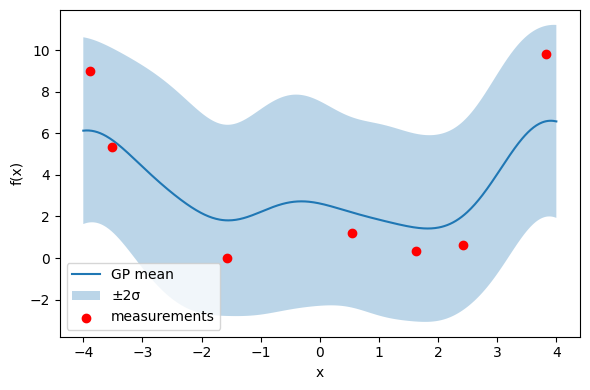

In [34]:
plt.figure(figsize=(6, 4))

# GP mean
plt.plot(x_grid, mean, label="GP mean")

# uncertainty band
plt.fill_between(
  x_grid,
  mean - 2 * std,
  mean + 2 * std,
  alpha=0.3,
  label="±2σ"
)

# training points
plt.scatter(x, y, color="red", zorder=3, label="measurements")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()

For simplicity, we treat time as the cost function. The cost of a single measurement is therefore equal to its acquisition time. In addition, we introduce a travel cost, which accounts for moving between measurement locations and is assumed to be proportional to the distance between them.

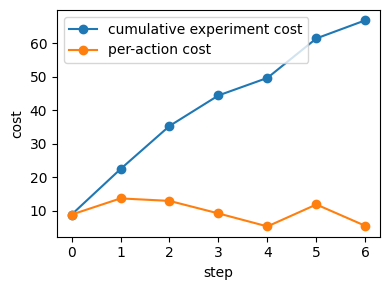

In [35]:
#@title total experiment cost

# initial position
x0 = 0

# displacement between consecutive points (including first move from x0)
dx = x - np.append(x0, x[:-1])

# cost of each action = travel cost + acquisition time
action_costs = travel_cost(dx) + t

# visualize costs
fig = plt.figure(figsize=(4,3))
plt.plot(np.cumsum(action_costs), 'o-', label='cumulative experiment cost')
plt.plot(action_costs, 'o-', label='per-action cost')

plt.xlabel('step')
plt.ylabel('cost')
plt.legend()
plt.tight_layout()




---


## Lets go!
---



Design a strategy that selects where to measure, in what order, and for how long, using the provided simulator and a fixed total budget. The objective is to explore or optimize the underlying function as efficiently as possible under noisy measurements and movement cost.

In [36]:
B = 100 #your budget

meas_sim = MeasurementSimulator(
    ground_truth_model=double_well, #choose gt function
    noise_model=noise_decay_floor,  #choose noise model
    rng=123,
)

In [37]:
#your code



We can interpret adaptive microscopy under budget and noise constraints as an optimal foraging problem. Measurement locations correspond to habitat patches, stage motion to travel cost, acquisition time to patch residence time, and information gained about the latent sample property to foraging reward. Because local observation quality improves with time but the global budget is finite, the agent faces a patch-leaving problem: remain and reduce uncertainty locally, or move and explore elsewhere.
The Core Problem
You have:

A landscape you don't know
A budget to explore it
Each observation costs something
Each move costs something
Observations are noisy


That's Classic Optimal Foraging Theory
From ecology/biology in the 1970s. A animal foraging for food faces exactly this:

A field with unknown food distribution
Energy cost to move between patches
Time cost to exploit a patch
Noisy "measurements" — you sniff around, not sure if food is there
Limited energy budget (or daylight)

The animal must decide:

Stay and keep eating here (exploit)
Move somewhere else (explore)

This is literally called the explore/exploit tradeoff and it's the heart of your problem too.

The Famous Result from Foraging Theory
The Marginal Value Theorem (Charnov, 1976) says:

Leave a patch when the rate of return drops below the average rate of the whole environment

In your microscope terms:

Stop acquiring at this position when the information gain per second drops below what you'd get on average elsewhere


That's your problem, exactly. And it has been studied for 50 years in ecology before anyone thought about it in materials science.

Total measurements : 12
Budget used        : 97.7 / 100

MAE at measured points : 0.0648
Domain coverage        : 87.65%


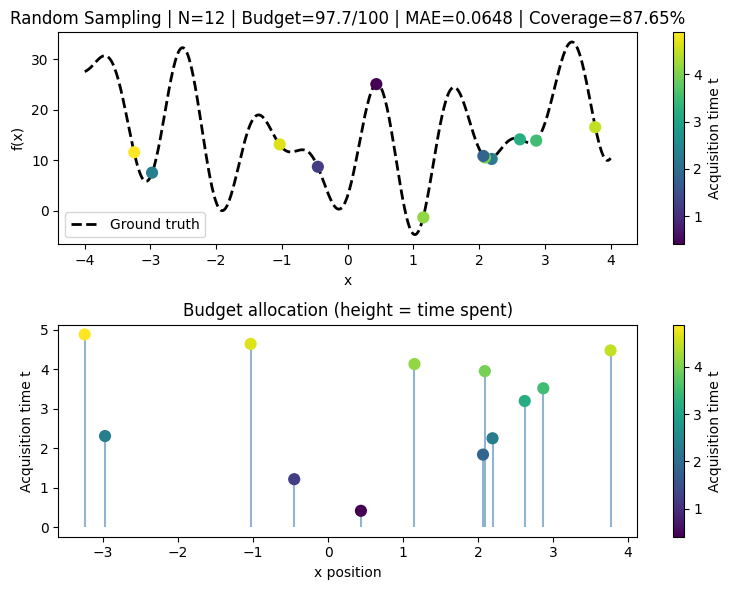

In [95]:
## lets try random sampling as base line
import numpy as np
import matplotlib.pyplot as plt

B            = 100
x_min, x_max = -4, 4
t_min, t_max =  0.1, 5
x_grid       = np.linspace(x_min, x_max, 500)

fx = multimodal
meas_sim = MeasurementSimulator(
    ground_truth_model=fx,
    noise_model=noise_constant,
    rng=123,
)

# ── random sampling loop ───────────────────────────────────────────────────
rng = np.random.default_rng(42)

x_current   = 0.0
budget_used = 0.0

xs_measured, ys_measured, ts_measured, costs = [], [], [], []

while True:
    x_next = rng.uniform(x_min, x_max)
    t_next = rng.uniform(t_min, t_max)
    cost   = travel_cost(x_next - x_current) + t_next

    if budget_used + cost > B:
        break

    y = meas_sim.measure(np.array([[x_next, t_next]]))[0]

    xs_measured.append(x_next)
    ys_measured.append(y)
    ts_measured.append(t_next)
    costs.append(cost)

    budget_used += cost
    x_current    = x_next

# ── convert to arrays ──────────────────────────────────────────────────────
xs_measured = np.array(xs_measured)
ys_measured = np.array(ys_measured)
ts_measured = np.array(ts_measured)
costs       = np.array(costs)
# ── metrics ────────────────────────────────────────────────────────────────
mae      = np.mean(np.abs(ys_measured - fx(xs_measured)))
coverage = (np.max(xs_measured) - np.min(xs_measured)) / (x_max - x_min)




print(f"Total measurements : {len(xs_measured)}")
print(f"Budget used        : {budget_used:.1f} / {B}")
print(f"\nMAE at measured points : {mae:.4f}")
print(f"Domain coverage        : {coverage:.2%}")

# ── plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# panel 1: measurements vs ground truth
ax = axes[0]
ax.plot(x_grid, fx(x_grid), 'k--', lw=2, label='Ground truth')
ax.scatter(xs_measured, ys_measured, c=ts_measured, cmap='viridis', s=60, zorder=5)
plt.colorbar(ax.collections[-1], ax=ax, label='Acquisition time t')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'Random Sampling | N={len(xs_measured)} | Budget={budget_used:.1f}/{B} | MAE={mae:.4f} | Coverage={coverage:.2%}')
ax.legend()

# panel 2: budget allocation
ax = axes[1]
ax.vlines(xs_measured, 0, ts_measured, color='steelblue', alpha=0.6)
ax.scatter(xs_measured, ts_measured, c=ts_measured, cmap='viridis', s=60, zorder=5)
plt.colorbar(ax.collections[-1], ax=ax, label='Acquisition time t')
ax.set_xlabel('x position')
ax.set_ylabel('Acquisition time t')
ax.set_title('Budget allocation (height = time spent)')

plt.tight_layout()
plt.show()

In [73]:
"""
Note: 
The GP Here Is Only For Plotting
It's used after all measurements are done just to:

Interpolate between the scattered measurements
Give a smooth curve to compare against ground truth
Show where we're uncertain (the ±2σ bands)

It's like fitting a curve to your data points in Origin or Igor after the experiment is done. Pure post-processing.
"""

"\nNote: \nThe GP Here Is Only For Plotting\nIt's used after all measurements are done just to:\n\nInterpolate between the scattered measurements\nGive a smooth curve to compare against ground truth\nShow where we're uncertain (the ±2σ bands)\n\nIt's like fitting a curve to your data points in Origin or Igor after the experiment is done. Pure post-processing.\n"

In [ ]:
# looks great for homoscadatic - lets try to break this for :
# - first differnt ground truth
# - then for differnt noise model

Phase 1 — 40 points, budget used: 32.0
Phase 2 — 7 points, budget used: 65.5
Total   — 47 points, budget used: 97.5/100

MAE at measured points : 0.1144
Domain coverage        : 100.00%


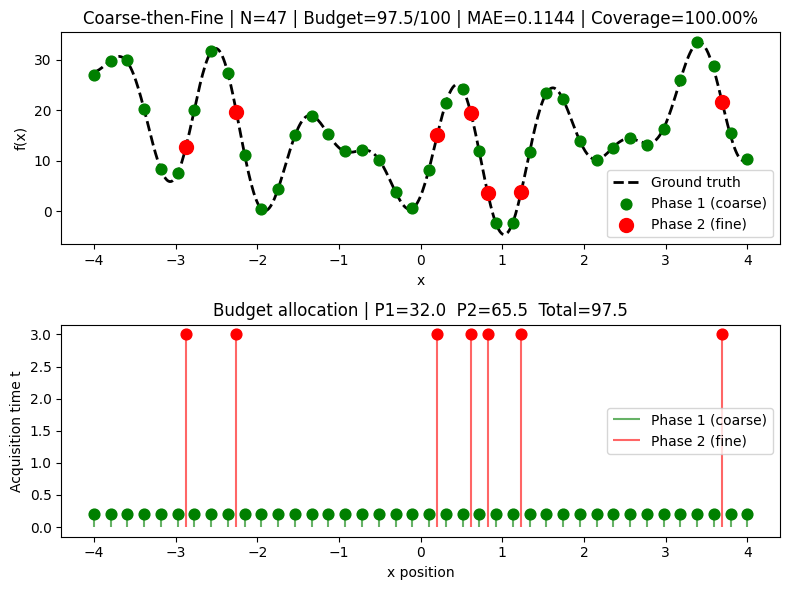

In [94]:
## method 2 - The simplest improvement over random would be the coarse-then-fine strategy I mentioned earlier:
### Phase 1 — spend say 40% of budget doing a quick uniform sweep with very short t — just to see the landscape 
### Phase 2 — spend remaining 60% going back to the interesting regions with longer t This directly mimics what you'd do intuitively at the microscope. 
### And it should obviously beat random because you're at least looking before you commit.
# ── setup ──────────────────────────────────────────────────────────────────
# ── setup ──────────────────────────────────────────────────────────────────
B            = 100
x_min, x_max = -4, 4
t_coarse     = 0.2
t_fine       = 3.0
phase1_frac  = 0.4
x_grid       = np.linspace(x_min, x_max, 500)

fx = multimodal
meas_sim = MeasurementSimulator(
    ground_truth_model=fx,
    noise_model=noise_heter_model,
    rng=123,
)

# ── phase 1: coarse uniform sweep ──────────────────────────────────────────
budget_p1   = B * phase1_frac
n_coarse    = int(budget_p1 / (travel_cost(8/20) + t_coarse))
x_coarse    = np.linspace(x_min, x_max, n_coarse)

xs_measured, ys_measured, ts_measured, costs, phase = [], [], [], [], []
x_current      = 0.0
budget_used_p1 = 0.0
budget_used_p2 = 0.0

for x_next in x_coarse:
    cost = travel_cost(x_next - x_current) + t_coarse
    if budget_used_p1 + cost > budget_p1:
        break
    y = meas_sim.measure(np.array([[x_next, t_coarse]]))[0]
    xs_measured.append(x_next); ys_measured.append(y)
    ts_measured.append(t_coarse); costs.append(cost); phase.append(1)
    budget_used_p1 += cost
    x_current       = x_next

print(f"Phase 1 — {sum(p==1 for p in phase)} points, budget used: {budget_used_p1:.1f}")

# ── find interesting regions: largest gaps ─────────────────────────────────
# sort phase 1 points by x
xs_arr   = np.array(xs_measured)
ys_arr   = np.array(ys_measured)

idx      = np.argsort(xs_arr)
x_sorted = xs_arr[idx]
y_sorted = ys_arr[idx]

# gradient and midpoints between adjacent phase 1 points
local_grad = np.abs(np.diff(y_sorted) / np.diff(x_sorted))
midpoints  = (x_sorted[1:] + x_sorted[:-1]) / 2

# steepest gradient first
x_refine   = midpoints[np.argsort(-local_grad)]

# ── phase 2: fill gaps until budget exhausted ──────────────────────────────
i = 0
while True:
    x_next = x_refine[i % len(x_refine)]
    cost   = travel_cost(x_next - x_current) + t_fine
    if budget_used_p1 + budget_used_p2 + cost > B:   # total budget check
        break
    y = meas_sim.measure(np.array([[x_next, t_fine]]))[0]
    xs_measured.append(x_next); ys_measured.append(y)
    ts_measured.append(t_fine); costs.append(cost); phase.append(2)
    budget_used_p2 += cost
    x_current       = x_next
    i += 1

budget_used = budget_used_p1 + budget_used_p2
print(f"Phase 2 — {sum(p==2 for p in phase)} points, budget used: {budget_used_p2:.1f}")
print(f"Total   — {len(xs_measured)} points, budget used: {budget_used:.1f}/{B}")

# ── convert to arrays ──────────────────────────────────────────────────────
xs_measured = np.array(xs_measured)
ys_measured = np.array(ys_measured)
ts_measured = np.array(ts_measured)
costs       = np.array(costs)
phase       = np.array(phase)

# ── metrics ────────────────────────────────────────────────────────────────
mae      = np.mean(np.abs(ys_measured - fx(xs_measured)))
coverage = (np.max(xs_measured) - np.min(xs_measured)) / (x_max - x_min)


print(f"\nMAE at measured points : {mae:.4f}")
print(f"Domain coverage        : {coverage:.2%}")

# ── plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# panel 1: measurements vs ground truth
ax = axes[0]
ax.plot(x_grid, fx(x_grid), 'k--', lw=2, label='Ground truth')
ax.scatter(xs_measured[phase==1], ys_measured[phase==1],
           color='green', s=60,  zorder=5, label='Phase 1 (coarse)')
ax.scatter(xs_measured[phase==2], ys_measured[phase==2],
           color='red',   s=100, zorder=5, label='Phase 2 (fine)')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'Coarse-then-Fine | N={len(xs_measured)} | Budget={budget_used:.1f}/{B} | MAE={mae:.4f} | Coverage={coverage:.2%}')
ax.legend()

# panel 2: budget allocation
ax = axes[1]
ax.vlines(xs_measured[phase==1], 0, ts_measured[phase==1],
          color='green', alpha=0.6, label='Phase 1 (coarse)')
ax.vlines(xs_measured[phase==2], 0, ts_measured[phase==2],
          color='red',   alpha=0.6, label='Phase 2 (fine)')
ax.scatter(xs_measured[phase==1], ts_measured[phase==1], color='green', s=60, zorder=5)
ax.scatter(xs_measured[phase==2], ts_measured[phase==2], color='red',   s=60, zorder=5)
ax.set_xlabel('x position')
ax.set_ylabel('Acquisition time t')
ax.set_title(f'Budget allocation | P1={budget_used_p1:.1f}  P2={budget_used_p2:.1f}  Total={budget_used:.1f}')
ax.legend()

plt.tight_layout()
plt.show()

Phase 1 — 49 points, budget used: 24.5
Phase 2 — 7 points, budget used: 73.2
Total   — 56 points, budget used: 97.7/100

MAE at measured points : 0.1221
Domain coverage        : 100.00%


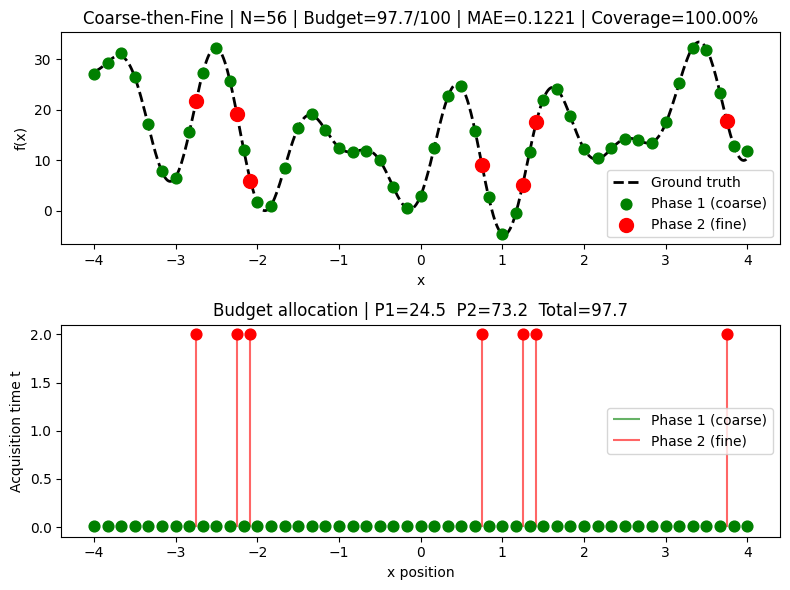

In [92]:
## method 2 - The simplest improvement over random would be the coarse-then-fine strategy I mentioned earlier:
### Phase 1 — spend say 40% of budget doing a quick uniform sweep with very short t — just to see the landscape 
### Phase 2 — spend remaining 60% going back to the interesting regions with longer t This directly mimics what you'd do intuitively at the microscope. 
### And it should obviously beat random because you're at least looking before you commit.
# ── setup ──────────────────────────────────────────────────────────────────
# ── setup ──────────────────────────────────────────────────────────────────
B            = 100
x_min, x_max = -4, 4
t_coarse     = 0.01
t_fine       = 2
phase1_frac  = 0.4
x_grid       = np.linspace(x_min, x_max, 500)

fx = multimodal
meas_sim = MeasurementSimulator(
    ground_truth_model=fx,
    noise_model=noise_heter_model,
    rng=123,
)

# ── phase 1: coarse uniform sweep ──────────────────────────────────────────
budget_p1   = B * phase1_frac
n_coarse    = int(budget_p1 / (travel_cost(8/20) + t_coarse))
x_coarse    = np.linspace(x_min, x_max, n_coarse)

xs_measured, ys_measured, ts_measured, costs, phase = [], [], [], [], []
x_current      = 0.0
budget_used_p1 = 0.0
budget_used_p2 = 0.0

for x_next in x_coarse:
    cost = travel_cost(x_next - x_current) + t_coarse
    if budget_used_p1 + cost > budget_p1:
        break
    y = meas_sim.measure(np.array([[x_next, t_coarse]]))[0]
    xs_measured.append(x_next); ys_measured.append(y)
    ts_measured.append(t_coarse); costs.append(cost); phase.append(1)
    budget_used_p1 += cost
    x_current       = x_next

print(f"Phase 1 — {sum(p==1 for p in phase)} points, budget used: {budget_used_p1:.1f}")

# ── find interesting regions: largest gaps ─────────────────────────────────
# sort phase 1 points by x
xs_arr   = np.array(xs_measured)
ys_arr   = np.array(ys_measured)

idx      = np.argsort(xs_arr)
x_sorted = xs_arr[idx]
y_sorted = ys_arr[idx]

# gradient and midpoints between adjacent phase 1 points
local_grad = np.abs(np.diff(y_sorted) / np.diff(x_sorted))
midpoints  = (x_sorted[1:] + x_sorted[:-1]) / 2

# noise at each midpoint (average of two neighbors)
sigma_left  = noise_decay_floor(x=x_sorted[:-1], t=t_coarse)
sigma_right = noise_decay_floor(x=x_sorted[1:],  t=t_coarse)
sigma_mid   = (sigma_left + sigma_right) / 2

# combined priority
priority = local_grad * sigma_mid

# sort by priority
x_refine = midpoints[np.argsort(-priority)]

# ── phase 2: fill gaps until budget exhausted ──────────────────────────────
i = 0
while True:
    x_next = x_refine[i % len(x_refine)]
    cost   = travel_cost(x_next - x_current) + t_fine
    if budget_used_p1 + budget_used_p2 + cost > B:   # total budget check
        break
    y = meas_sim.measure(np.array([[x_next, t_fine]]))[0]
    xs_measured.append(x_next); ys_measured.append(y)
    ts_measured.append(t_fine); costs.append(cost); phase.append(2)
    budget_used_p2 += cost
    x_current       = x_next
    i += 1

budget_used = budget_used_p1 + budget_used_p2
print(f"Phase 2 — {sum(p==2 for p in phase)} points, budget used: {budget_used_p2:.1f}")
print(f"Total   — {len(xs_measured)} points, budget used: {budget_used:.1f}/{B}")

# ── convert to arrays ──────────────────────────────────────────────────────
xs_measured = np.array(xs_measured)
ys_measured = np.array(ys_measured)
ts_measured = np.array(ts_measured)
costs       = np.array(costs)
phase       = np.array(phase)

# ── metrics ────────────────────────────────────────────────────────────────
mae      = np.mean(np.abs(ys_measured - fx(xs_measured)))
coverage = (np.max(xs_measured) - np.min(xs_measured)) / (x_max - x_min)


print(f"\nMAE at measured points : {mae:.4f}")
print(f"Domain coverage        : {coverage:.2%}")

# ── plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# panel 1: measurements vs ground truth
ax = axes[0]
ax.plot(x_grid, fx(x_grid), 'k--', lw=2, label='Ground truth')
ax.scatter(xs_measured[phase==1], ys_measured[phase==1],
           color='green', s=60,  zorder=5, label='Phase 1 (coarse)')
ax.scatter(xs_measured[phase==2], ys_measured[phase==2],
           color='red',   s=100, zorder=5, label='Phase 2 (fine)')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'Coarse-then-Fine | N={len(xs_measured)} | Budget={budget_used:.1f}/{B} | MAE={mae:.4f} | Coverage={coverage:.2%}')
ax.legend()

# panel 2: budget allocation
ax = axes[1]
ax.vlines(xs_measured[phase==1], 0, ts_measured[phase==1],
          color='green', alpha=0.6, label='Phase 1 (coarse)')
ax.vlines(xs_measured[phase==2], 0, ts_measured[phase==2],
          color='red',   alpha=0.6, label='Phase 2 (fine)')
ax.scatter(xs_measured[phase==1], ts_measured[phase==1], color='green', s=60, zorder=5)
ax.scatter(xs_measured[phase==2], ts_measured[phase==2], color='red',   s=60, zorder=5)
ax.set_xlabel('x position')
ax.set_ylabel('Acquisition time t')
ax.set_title(f'Budget allocation | P1={budget_used_p1:.1f}  P2={budget_used_p2:.1f}  Total={budget_used:.1f}')
ax.legend()

plt.tight_layout()
plt.show()

## do 3 phases

Phase 1a — 6 points, budget used: 19.5
Phase 1b — 2 points, budget used: 18.3
Noise estimates : {-4.0: 0.1411835834458781, -0.5714285714285716: 0.01932792018293142}
Phase 2  — 8 points, budget used: 58.3
Total    — 16 points, budget used: 96.1/100

MAE at measured points : 0.1003
Domain coverage        : 71.43%


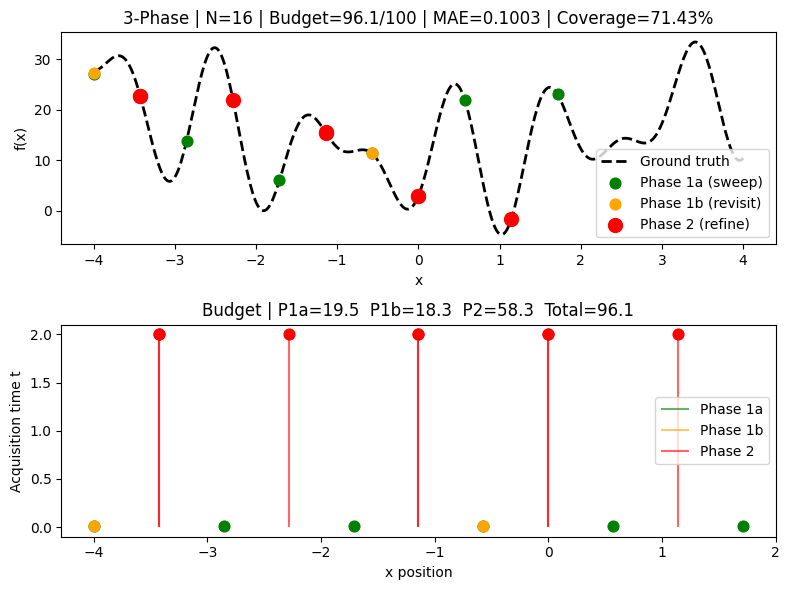

In [93]:
B            = 100
x_min, x_max = -4, 4
t_coarse     = 0.01
t_fine       = 2
phase1_frac  = 0.4
x_grid       = np.linspace(x_min, x_max, 500)

fx = multimodal
meas_sim = MeasurementSimulator(
    ground_truth_model=fx,
    noise_model=noise_heter_model,
    rng=123,
)


# ── phase 1a: sparse sweep ─────────────────────────────────────────────────
budget_p1a  = B * 0.2          # 20% for landscape
n_coarse    = 8                # fixed sparse points
x_coarse    = np.linspace(x_min, x_max, n_coarse)

xs_measured, ys_measured, ts_measured, costs, phase = [], [], [], [], []
x_current       = 0.0
budget_used_p1a = 0.0
budget_used_p1b = 0.0
budget_used_p2  = 0.0

for x_next in x_coarse:
    cost = travel_cost(x_next - x_current) + t_coarse
    if budget_used_p1a + cost > budget_p1a:
        break
    y = meas_sim.measure(np.array([[x_next, t_coarse]]))[0]
    xs_measured.append(x_next); ys_measured.append(y)
    ts_measured.append(t_coarse); costs.append(cost); phase.append(1)
    budget_used_p1a += cost
    x_current        = x_next

print(f"Phase 1a — {sum(p==1 for p in phase)} points, budget used: {budget_used_p1a:.1f}")

# ── phase 1b: revisit each point once to estimate noise ───────────────────
budget_p1b = B * 0.2           # 20% for noise estimation

xs_arr   = np.array(xs_measured)
ys_arr   = np.array(ys_measured)

# sort by x for gradient computation
idx      = np.argsort(xs_arr)
x_sorted = xs_arr[idx]
y_sorted = ys_arr[idx]

# gradient at each point — to prioritize which to revisit
local_grad = np.abs(np.diff(y_sorted) / np.diff(x_sorted))
midpoints  = (x_sorted[1:] + x_sorted[:-1]) / 2

# revisit the original coarse points sorted by gradient
x_revisit = x_sorted[np.argsort(-np.append(local_grad, local_grad[-1]))]

ys_revisit  = {}   # store second measurement at each point

for x_next in x_revisit:
    cost = travel_cost(x_next - x_current) + t_coarse
    if budget_used_p1b + cost > budget_p1b:
        break
    y = meas_sim.measure(np.array([[x_next, t_coarse]]))[0]
    xs_measured.append(x_next); ys_measured.append(y)
    ts_measured.append(t_coarse); costs.append(cost); phase.append(2)
    ys_revisit[x_next] = y     # store for noise estimation
    budget_used_p1b    += cost
    x_current           = x_next

print(f"Phase 1b — {sum(p==2 for p in phase)} points, budget used: {budget_used_p1b:.1f}")

# ── estimate local noise from repeated measurements ────────────────────────
# noise estimate = |y1 - y2| / sqrt(2) at revisited points
noise_estimates = {}
xs_arr_all = np.array(xs_measured)
ys_arr_all = np.array(ys_measured)

for x_pt in ys_revisit:
    mask  = xs_arr_all == x_pt
    y_all = ys_arr_all[mask]
    if len(y_all) >= 2:
        noise_estimates[x_pt] = np.abs(y_all[0] - y_all[1]) / np.sqrt(2)

print(f"Noise estimates : {noise_estimates}")

# ── phase 2: gradient × noise / cost ──────────────────────────────────────
# for midpoints, interpolate noise from nearest revisited point
def get_noise_estimate(x, noise_estimates, default=1.0):
    if not noise_estimates:
        return default
    xs_n = np.array(list(noise_estimates.keys()))
    ys_n = np.array(list(noise_estimates.values()))
    return ys_n[np.argmin(np.abs(xs_n - x))]   # nearest neighbor

# priority = gradient × noise / cost
priorities = []
for i, x_mid in enumerate(midpoints):
    noise    = get_noise_estimate(x_mid, noise_estimates)
    cost     = travel_cost(x_mid - x_current) + t_fine
    priority = (local_grad[i] * noise) / cost
    priorities.append(priority)

x_refine = midpoints[np.argsort(-np.array(priorities))]

# ── phase 2: measure until budget exhausted ────────────────────────────────
i = 0
while True:
    x_next = x_refine[i % len(x_refine)]
    cost   = travel_cost(x_next - x_current) + t_fine
    if budget_used_p1a + budget_used_p1b + budget_used_p2 + cost > B:
        break
    y = meas_sim.measure(np.array([[x_next, t_fine]]))[0]
    xs_measured.append(x_next); ys_measured.append(y)
    ts_measured.append(t_fine); costs.append(cost); phase.append(3)
    budget_used_p2 += cost
    x_current       = x_next
    i += 1

budget_used = budget_used_p1a + budget_used_p1b + budget_used_p2
print(f"Phase 2  — {sum(p==3 for p in phase)} points, budget used: {budget_used_p2:.1f}")
print(f"Total    — {len(xs_measured)} points, budget used: {budget_used:.1f}/{B}")

# ── convert to arrays ──────────────────────────────────────────────────────
xs_measured = np.array(xs_measured)
ys_measured = np.array(ys_measured)
ts_measured = np.array(ts_measured)
costs       = np.array(costs)
phase       = np.array(phase)

# ── metrics ────────────────────────────────────────────────────────────────
mae      = np.mean(np.abs(ys_measured - fx(xs_measured)))
coverage = (np.max(xs_measured) - np.min(xs_measured)) / (x_max - x_min)


print(f"\nMAE at measured points : {mae:.4f}")
print(f"Domain coverage        : {coverage:.2%}")

# ── plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

ax = axes[0]
ax.plot(x_grid, fx(x_grid), 'k--', lw=2, label='Ground truth')
ax.scatter(xs_measured[phase==1], ys_measured[phase==1],
           color='green',  s=60,  zorder=5, label='Phase 1a (sweep)')
ax.scatter(xs_measured[phase==2], ys_measured[phase==2],
           color='orange', s=60,  zorder=5, label='Phase 1b (revisit)')
ax.scatter(xs_measured[phase==3], ys_measured[phase==3],
           color='red',    s=100, zorder=5, label='Phase 2 (refine)')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'3-Phase | N={len(xs_measured)} | Budget={budget_used:.1f}/{B} | MAE={mae:.4f} | Coverage={coverage:.2%}')
ax.legend()

ax = axes[1]
ax.vlines(xs_measured[phase==1], 0, ts_measured[phase==1], color='green',  alpha=0.6, label='Phase 1a')
ax.vlines(xs_measured[phase==2], 0, ts_measured[phase==2], color='orange', alpha=0.6, label='Phase 1b')
ax.vlines(xs_measured[phase==3], 0, ts_measured[phase==3], color='red',    alpha=0.6, label='Phase 2')
ax.scatter(xs_measured[phase==1], ts_measured[phase==1], color='green',  s=60, zorder=5)
ax.scatter(xs_measured[phase==2], ts_measured[phase==2], color='orange', s=60, zorder=5)
ax.scatter(xs_measured[phase==3], ts_measured[phase==3], color='red',    s=60, zorder=5)
ax.set_xlabel('x position')
ax.set_ylabel('Acquisition time t')
ax.set_title(f'Budget | P1a={budget_used_p1a:.1f}  P1b={budget_used_p1b:.1f}  P2={budget_used_p2:.1f}  Total={budget_used:.1f}')
ax.legend()

plt.tight_layout()
plt.show()